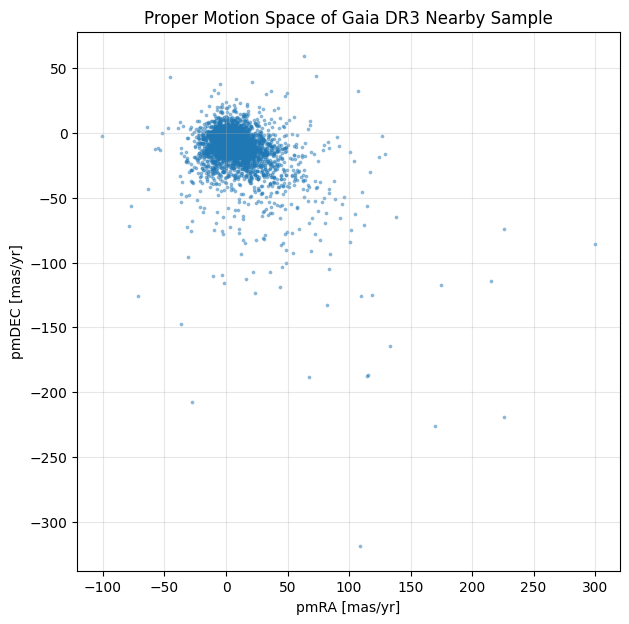

Saved figure to: /Users/liors/Documents/gaia-lamost-galactic-archaeology/figures/gaia_dr3_nearby_5000_proper_motion_space.png


In [13]:
plt.figure(figsize=(7, 7))

plt.scatter(
    gaia_df["pmra"],
    gaia_df["pmdec"],
    s=3,
    alpha=0.4
)

plt.xlabel("pmRA [mas/yr]")
plt.ylabel("pmDEC [mas/yr]")
plt.title("Proper Motion Space of Gaia DR3 Nearby Sample")

plt.grid(alpha=0.3)

pm_path = PROJECT_ROOT / "figures" / "gaia_dr3_nearby_5000_proper_motion_space.png"
plt.savefig(pm_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved figure to:", pm_path)

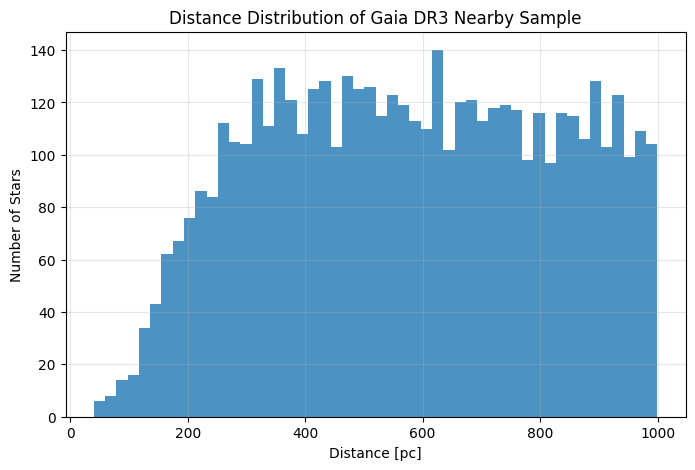

Saved figure to: /Users/liors/Documents/gaia-lamost-galactic-archaeology/figures/gaia_dr3_nearby_5000_distance_distribution.png


In [12]:
plt.figure(figsize=(8, 5))

plt.hist(
    gaia_df["distance_pc"],
    bins=50,
    alpha=0.8
)

plt.xlabel("Distance [pc]")
plt.ylabel("Number of Stars")
plt.title("Distance Distribution of Gaia DR3 Nearby Sample")

plt.grid(alpha=0.3)

distance_path = PROJECT_ROOT / "figures" / "gaia_dr3_nearby_5000_distance_distribution.png"
plt.savefig(distance_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved figure to:", distance_path)

## Initial Validation Summary

The Gaia DR3 query successfully returned 5,000 nearby stars with reliable parallaxes and astrometric quality cuts.

Three validation plots were generated:

1. A color-magnitude diagram showing a clear main sequence.
2. A distance distribution confirming that the sample covers the nearby 0–1000 pc range.
3. A proper motion diagram showing the kinematic spread of the nearby stellar sample.

These results confirm that the initial Gaia DR3 data extraction and feature construction pipeline is working correctly.

The next step is to extend the sample and prepare for Gaia–LAMOST cross-matching.

## Color-Magnitude Diagram

The color-magnitude diagram (CMD) is constructed using Gaia BP-RP color and the derived absolute G-band magnitude.

A clear main sequence is visible in the nearby stellar sample, indicating that the Gaia query, parallax-based distance estimation, and absolute magnitude calculation are working as expected.

This figure serves as the first validation plot of the Gaia DR3 data extraction pipeline.

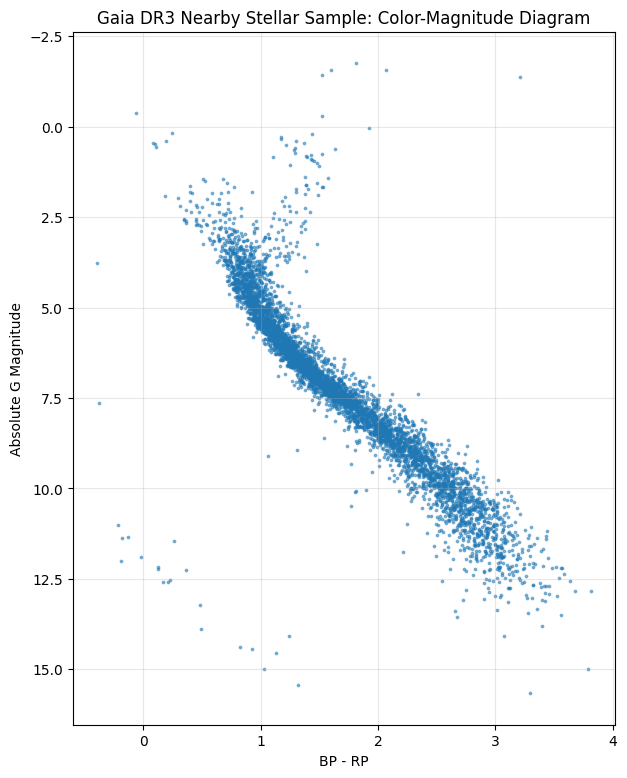

Saved figure to: /Users/liors/Documents/gaia-lamost-galactic-archaeology/figures/gaia_dr3_nearby_5000_cmd.png


In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 9))

plt.scatter(
    gaia_df["bp_rp"],
    gaia_df["absolute_g_mag"],
    s=3,
    alpha=0.5
)

plt.gca().invert_yaxis()

plt.xlabel("BP - RP")
plt.ylabel("Absolute G Magnitude")
plt.title("Gaia DR3 Nearby Stellar Sample: Color-Magnitude Diagram")

plt.grid(alpha=0.3)

cmd_path = PROJECT_ROOT / "figures" / "gaia_dr3_nearby_5000_cmd.png"
plt.savefig(cmd_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved figure to:", cmd_path)

In [10]:
processed_output_path = PROCESSED_DATA_DIR / "gaia_dr3_nearby_5000_with_features.csv"

gaia_df.to_csv(processed_output_path, index=False)

print("Saved to:", processed_output_path)

Saved to: /Users/liors/Documents/gaia-lamost-galactic-archaeology/data/processed/gaia_dr3_nearby_5000_with_features.csv


In [9]:
import numpy as np

gaia_df["distance_pc"] = 1000 / gaia_df["parallax"]

gaia_df["absolute_g_mag"] = (
    gaia_df["phot_g_mean_mag"]
    - 5 * np.log10(gaia_df["distance_pc"])
    + 5
)

gaia_df[[
    "source_id",
    "parallax",
    "distance_pc",
    "phot_g_mean_mag",
    "absolute_g_mag",
    "bp_rp"
]].head()

,source_id,parallax,distance_pc,phot_g_mean_mag,absolute_g_mag,bp_rp
0,137342166385242112,4.299332,232.594299,14.220328,7.387333,1.699450
1,137351615313312384,1.354746,738.145960,12.139791,2.799079,0.969991
2,137355081351966336,3.981490,251.162249,19.214495,12.214723,2.952120
3,137355326165033472,1.222841,817.767640,16.461163,6.898013,1.636908
4,137356941072665344,1.040854,960.749715,16.809561,6.896509,1.566496


In [8]:
gaia_df.describe()

,source_id,ra,dec,parallax,parallax_error,parallax_over_error,pmra,pmra_error,pmdec,pmdec_error,phot_g_mean_mag,bp_rp,radial_velocity,radial_velocity_error,ruwe
count,5.000000e+03,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,1482.000000,1482.000000,5000.000000
mean,1.417745e+17,45.710485,37.355585,2.263436,0.079772,50.295830,6.727144,0.088739,-10.207889,0.077923,15.853172,1.713422,-7.312985,4.472773,1.032858
std,7.006144e+15,5.701865,1.398411,1.645398,0.070816,62.332314,18.632000,0.083862,16.677624,0.072402,2.028305,0.699996,39.178661,3.232920,0.083649
min,1.373333e+17,40.799767,35.298733,1.000138,0.011639,10.012048,-100.856766,0.011950,-318.839934,0.008793,6.420301,-0.390226,-187.471359,0.121433,0.737352
25%,1.394245e+17,43.368606,36.615045,1.277206,0.027876,16.748689,-2.521225,0.029647,-13.620193,0.026171,14.541382,1.124515,-27.637602,2.267501,0.978456
50%,1.414761e+17,45.144233,37.155057,1.734874,0.057858,30.469656,3.650811,0.063754,-7.093004,0.055532,16.224208,1.595237,-6.751097,3.925549,1.021508
75%,1.420535e+17,46.845829,37.741283,2.651551,0.105698,60.133162,11.941151,0.117940,-2.566477,0.104046,17.370283,2.265268,12.697042,6.021242,1.074535
max,1.972762e+17,89.971768,46.194615,24.995109,0.903200,1240.783325,300.047123,1.542566,59.116059,0.886966,20.231026,3.810644,770.128052,30.418144,1.398313


In [7]:
gaia_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   source_id              5000 non-null   int64  
 1   ra                     5000 non-null   float64
 2   dec                    5000 non-null   float64
 3   parallax               5000 non-null   float64
 4   parallax_error         5000 non-null   float32
 5   parallax_over_error    5000 non-null   float32
 6   pmra                   5000 non-null   float64
 7   pmra_error             5000 non-null   float32
 8   pmdec                  5000 non-null   float64
 9   pmdec_error            5000 non-null   float32
 10  phot_g_mean_mag        5000 non-null   float32
 11  bp_rp                  5000 non-null   float32
 12  radial_velocity        1482 non-null   float32
 13  radial_velocity_error  1482 non-null   float32
 14  ruwe                   5000 non-null   float32
dtypes: float32(9), 

In [6]:
output_path = RAW_DATA_DIR / "gaia_dr3_nearby_5000.csv"

gaia_df.to_csv(output_path, index=False)

print("Saved to:", output_path)

Saved to: /Users/liors/Documents/gaia-lamost-galactic-archaeology/data/raw/gaia_dr3_nearby_5000.csv


In [5]:
output_path = RAW_DATA_DIR / "gaia_dr3_nearby_5000.csv"

gaia_df.to_csv(output_path, index=False)

print("Saved to:", output_path)

Saved to: /Users/liors/Documents/gaia-lamost-galactic-archaeology/data/raw/gaia_dr3_nearby_5000.csv


In [4]:
job = Gaia.launch_job_async(query)
results = job.get_results()

gaia_df = results.to_pandas()

print("Number of stars:", len(gaia_df))
gaia_df.head()

INFO: Query finished. [astroquery.utils.tap.core]
Number of stars: 5000


,source_id,ra,dec,parallax,parallax_error,parallax_over_error,pmra,pmra_error,pmdec,pmdec_error,phot_g_mean_mag,bp_rp,radial_velocity,radial_velocity_error,ruwe
0,137342166385242112,45.180216,35.491308,4.299332,0.022674,189.618149,16.168014,0.024834,-7.158580,0.022579,14.220328,1.699450,-17.381996,2.947937,1.026791
1,137351615313312384,45.040013,35.385282,1.354746,0.018821,71.981308,4.779749,0.020588,2.517139,0.019119,12.139791,0.969991,7.051328,0.589513,1.202068
2,137355081351966336,45.115899,35.554198,3.981490,0.322516,12.345096,32.056111,0.420529,-13.308357,0.371145,19.214495,2.952120,NaN,NaN,0.991183
3,137355326165033472,45.072703,35.574909,1.222841,0.056203,21.757740,11.164154,0.067539,-17.299641,0.061992,16.461163,1.636908,NaN,NaN,1.006233
4,137356941072665344,44.875544,35.521475,1.040854,0.084224,12.358170,7.182431,0.091817,-9.415568,0.082717,16.809561,1.566496,NaN,NaN,1.221099


In [3]:
query = """
SELECT TOP 5000
    source_id,
    ra,
    dec,
    parallax,
    parallax_error,
    parallax_over_error,
    pmra,
    pmra_error,
    pmdec,
    pmdec_error,
    phot_g_mean_mag,
    bp_rp,
    radial_velocity,
    radial_velocity_error,
    ruwe
FROM gaiadr3.gaia_source
WHERE parallax > 1
  AND parallax_over_error > 10
  AND pmra IS NOT NULL
  AND pmdec IS NOT NULL
  AND phot_g_mean_mag IS NOT NULL
  AND bp_rp IS NOT NULL
  AND ruwe < 1.4
"""

In [2]:
PROJECT_ROOT = Path("..").resolve()

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw data directory:", RAW_DATA_DIR)
print("Processed data directory:", PROCESSED_DATA_DIR)

Project root: /Users/liors/Documents/gaia-lamost-galactic-archaeology
Raw data directory: /Users/liors/Documents/gaia-lamost-galactic-archaeology/data/raw
Processed data directory: /Users/liors/Documents/gaia-lamost-galactic-archaeology/data/processed


In [1]:
from astroquery.gaia import Gaia
import pandas as pd
from pathlib import Path

print("Gaia imported successfully")
print("pandas version:", pd.__version__)

In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).
Gaia imported successfully
pandas version: 3.0.3
